#  Email/SMS Spam Classifier

**Internship Project — CodTech**

A machine learning project to classify SMS/email messages as **Spam** or **Ham** (not spam), using Natural Language Processing and classic ML algorithms.


## 🎯 2. Objective

The goal of this project is to build a model that can automatically detect whether a text message is spam or not.

Steps involved:
- Understand and clean the dataset
- Explore the data using visualizations
- Preprocess the text (cleaning, removing stopwords, etc.)
- Convert text into numerical form using TF-IDF
- Train and compare three machine learning models
- Evaluate which model performs best
- Test the final model on new, custom messages


## 📚 3. Import Libraries

In [18]:
import pandas as pd
import numpy as np
import re
import string

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

import nltk
from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
sns.set_style('whitegrid')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


## 📂 4. Load Dataset

Upload `spam.csv` to your Colab session before running this cell (click the folder icon on the left sidebar → upload file).


In [19]:
df = pd.read_csv('spam.csv', encoding='latin-1')
df.head()


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [20]:
# The original Kaggle file has some extra empty columns, so we only keep the useful ones
df = df[['v1', 'v2']]
df.columns = ['label', 'message']
df.head()


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## 🔍 5. Dataset Overview

In [21]:
print("Shape of dataset:", df.shape)
df.info()


Shape of dataset: (5572, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [22]:
df.describe(include='object')


,label,message
count,5572,5572
unique,2,5169
top,ham,"Sorry, I'll call later"
freq,4825,30


In [23]:
df['label'].value_counts()


,count
label,
ham,4825
spam,747


## 🧹 6. Data Cleaning

In [24]:
# Check for missing values
df.isnull().sum()


,0
label,0
message,0


In [25]:
# Check for duplicate messages
print("Duplicate rows:", df.duplicated().sum())

# Remove duplicates
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)


Duplicate rows: 403
Shape after removing duplicates: (5169, 2)


In [26]:
# Convert labels to numbers: ham = 0, spam = 1
df['label_num'] = df['label'].map({'ham': 0, 'spam': 1})
df.head()


,label,message,label_num
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


## 📊 7. Exploratory Data Analysis (EDA)

### Graph 1: Spam vs Ham Distribution


/tmp/ipykernel_3694/3472648947.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, palette=['#4CAF50', '#E53935'])


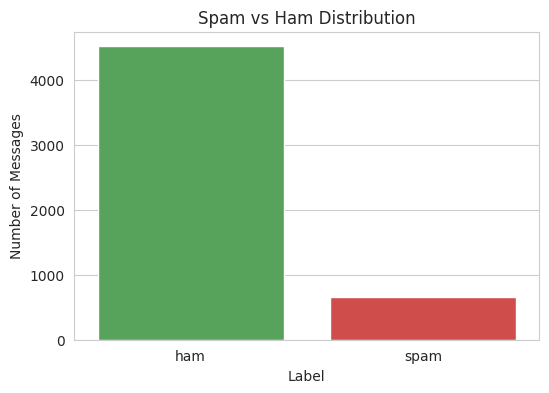

label
ham     87.366996
spam    12.633004
Name: proportion, dtype: float64


In [27]:
plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df, palette=['#4CAF50', '#E53935'])
plt.title('Spam vs Ham Distribution')
plt.xlabel('Label')
plt.ylabel('Number of Messages')
plt.show()

print(df['label'].value_counts(normalize=True) * 100)


**Observation:** The dataset is imbalanced — there are many more ham messages than spam messages. This is normal for real-world spam datasets.

## 🛠️ 8. Feature Engineering

Before cleaning the text for the model, let's create a few extra numeric features that might help us understand the data better:
- Number of characters in a message
- Number of words in a message
- Number of sentences in a message


In [28]:
df['num_characters'] = df['message'].apply(len)
df['num_words'] = df['message'].apply(lambda x: len(nltk.word_tokenize(x)))
df['num_sentences'] = df['message'].apply(lambda x: len(nltk.sent_tokenize(x)))

df[['num_characters', 'num_words', 'num_sentences']].describe()


,num_characters,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


### Graph 2: Message Length Distribution

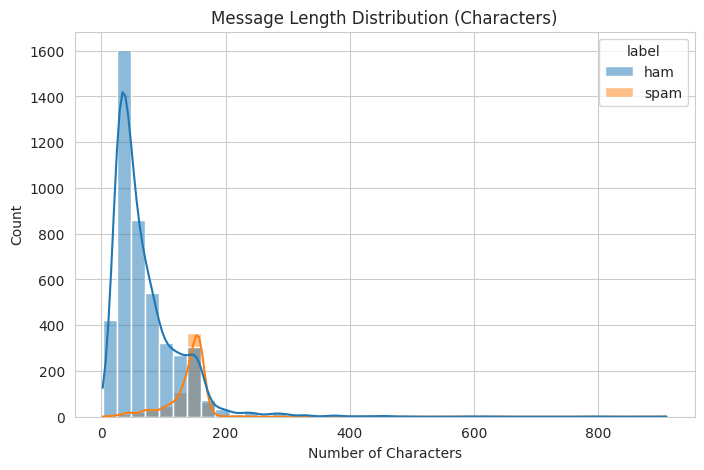

In [29]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='num_characters', hue='label', bins=40, kde=True)
plt.title('Message Length Distribution (Characters)')
plt.xlabel('Number of Characters')
plt.show()


### Graph 3: Word Count Distribution

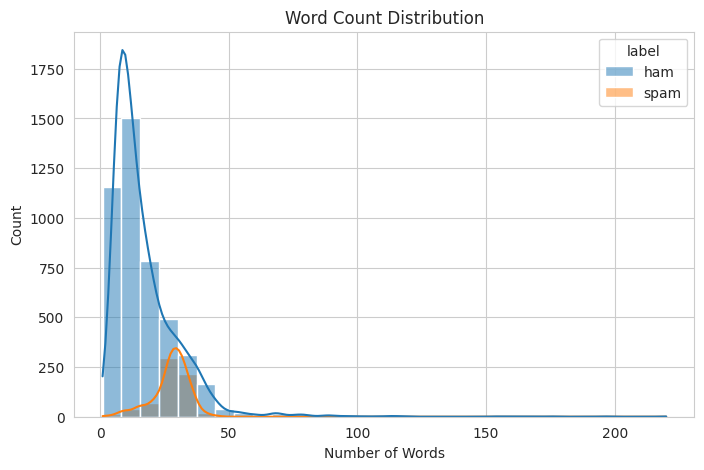

In [30]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='num_words', hue='label', bins=30, kde=True)
plt.title('Word Count Distribution')
plt.xlabel('Number of Words')
plt.show()


**Observation:** Spam messages tend to be longer, both in characters and in words, compared to normal (ham) messages. This makes sense since spam messages often contain promotional text, links, and offers.

### Graph 4: Correlation Heatmap

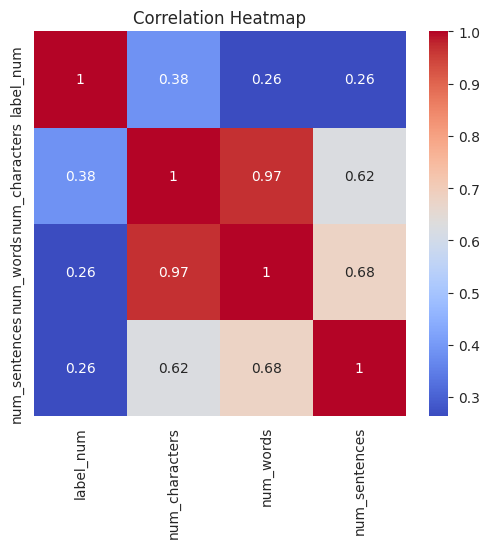

In [31]:
plt.figure(figsize=(6,5))
sns.heatmap(df[['label_num','num_characters','num_words','num_sentences']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


**Observation:** `num_characters` and `num_words` have a noticeable positive correlation with the label (spam), which matches what we saw in the graphs above.

## ✂️ 9. Text Preprocessing

Before feeding text to a machine learning model, we need to clean it:
- Convert to lowercase
- Remove punctuation and numbers
- Remove common "stopwords" (like "the", "is", "and") that don't carry much meaning


In [32]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()                                   # lowercase
    text = re.sub(r'\d+', '', text)                        # remove numbers
    text = text.translate(str.maketrans('', '', string.punctuation))  # remove punctuation
    words = text.split()
    words = [word for word in words if word not in stop_words]  # remove stopwords
    return " ".join(words)

# Quick test
print(clean_text("Hey!! Call 12345 now to WIN a free prize."))


hey call win free prize


In [33]:
df['clean_message'] = df['message'].apply(clean_text)
df[['message', 'clean_message']].head()


,message,clean_message
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...
3,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,"Nah I don't think he goes to usf, he lives aro...",nah dont think goes usf lives around though


## ☁️ 10. Word Clouds

Word clouds help us visualize the most frequently used words in spam and ham messages.

### Graph 5: Spam Word Cloud


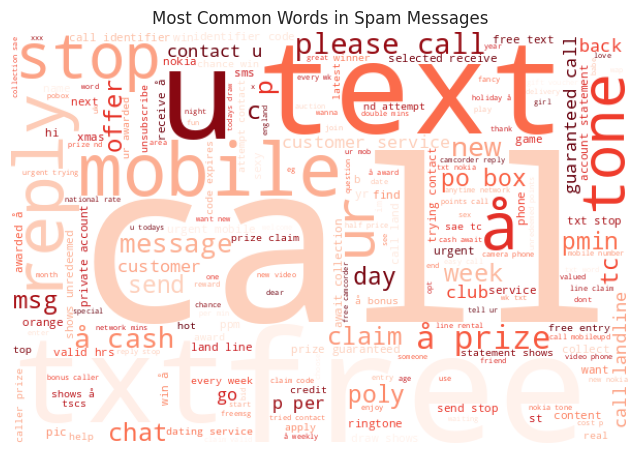

In [34]:
spam_text = df[df['label'] == 'spam']['clean_message'].str.cat(sep=' ')
spam_wc = WordCloud(width=600, height=400, background_color='white', colormap='Reds').generate(spam_text)

plt.figure(figsize=(8,6))
plt.imshow(spam_wc)
plt.axis('off')
plt.title('Most Common Words in Spam Messages')
plt.show()


### Graph 6: Ham Word Cloud

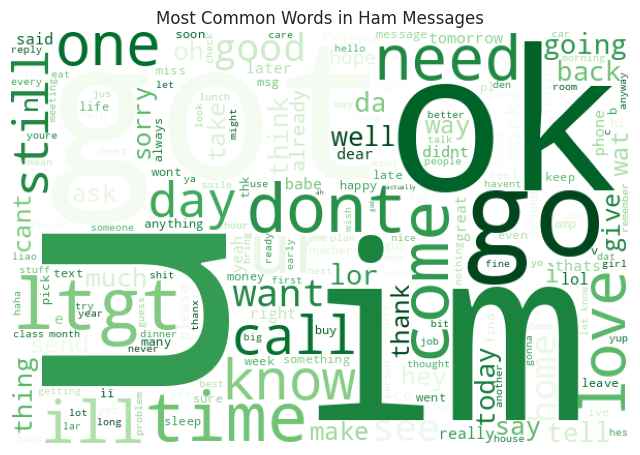

In [35]:
ham_text = df[df['label'] == 'ham']['clean_message'].str.cat(sep=' ')
ham_wc = WordCloud(width=600, height=400, background_color='white', colormap='Greens').generate(ham_text)

plt.figure(figsize=(8,6))
plt.imshow(ham_wc)
plt.axis('off')
plt.title('Most Common Words in Ham Messages')
plt.show()


**Observation:** Spam messages frequently contain words like *free*, *win*, *call*, *text*, and *claim*, while ham messages contain more everyday, conversational words.

## 🔢 11. TF-IDF Vectorization

Machine learning models only understand numbers, not raw text. We use **TF-IDF (Term Frequency – Inverse Document Frequency)** to convert each message into a numeric vector based on the words it contains.


In [36]:
tfidf = TfidfVectorizer(max_features=3000)
X = tfidf.fit_transform(df['clean_message']).toarray()
y = df['label_num']

print("Shape of feature matrix:", X.shape)


Shape of feature matrix: (5169, 3000)


## ✂️ 12. Train-Test Split

In [37]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


Training samples: 4135
Testing samples: 1034


## 🤖 13. Model Training

We will train and compare three commonly used classification models:
- **Multinomial Naive Bayes** — a classic algorithm often used for spam detection
- **Logistic Regression** — a simple and popular classification algorithm
- **Random Forest** — an ensemble of decision trees that often improves accuracy


In [38]:
models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

predictions = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    predictions[name] = y_pred
    print(f"{name} trained successfully.")


Naive Bayes trained successfully.
Logistic Regression trained successfully.
Random Forest trained successfully.


## 📈 14. Model Evaluation

### Comparing Accuracy, Precision, Recall, and F1-Score


In [39]:
results = []

for name, y_pred in predictions.items():
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    results.append({"Model": name, "Accuracy": acc, "Precision": prec, "Recall": rec, "F1-Score": f1})

results_df = pd.DataFrame(results)
results_df


,Model,Accuracy,Precision,Recall,F1-Score
0,Naive Bayes,0.972921,0.990476,0.793893,0.881356
1,Logistic Regression,0.949710,0.975904,0.618321,0.757009
2,Random Forest,0.974855,0.981651,0.816794,0.891667


### Graph 7: Model Comparison

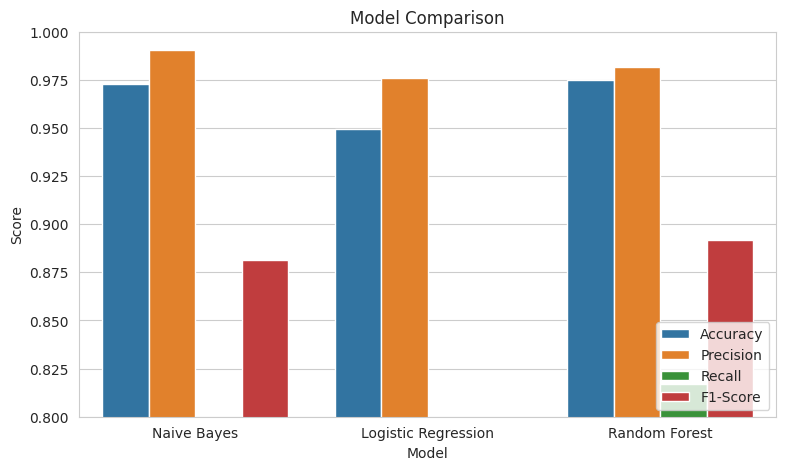

In [40]:
results_melted = results_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(9,5))
sns.barplot(data=results_melted, x='Model', y='Score', hue='Metric')
plt.title('Model Comparison')
plt.ylim(0.8, 1.0)
plt.legend(loc='lower right')
plt.show()


In [41]:
for name, y_pred in predictions.items():
    print(f"----- {name} -----")
    print(classification_report(y_test, y_pred, target_names=['Ham','Spam']))


----- Naive Bayes -----
              precision    recall  f1-score   support

         Ham       0.97      1.00      0.98       903
        Spam       0.99      0.79      0.88       131

    accuracy                           0.97      1034
   macro avg       0.98      0.90      0.93      1034
weighted avg       0.97      0.97      0.97      1034

----- Logistic Regression -----
              precision    recall  f1-score   support

         Ham       0.95      1.00      0.97       903
        Spam       0.98      0.62      0.76       131

    accuracy                           0.95      1034
   macro avg       0.96      0.81      0.86      1034
weighted avg       0.95      0.95      0.94      1034

----- Random Forest -----
              precision    recall  f1-score   support

         Ham       0.97      1.00      0.99       903
        Spam       0.98      0.82      0.89       131

    accuracy                           0.97      1034
   macro avg       0.98      0.91      0.94   

### Graph 8: Confusion Matrix (Best Model)

Best model based on Precision: Naive Bayes


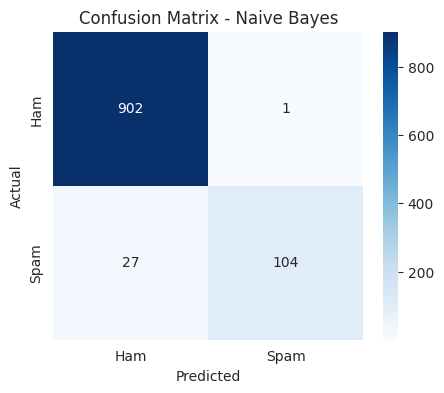

In [42]:
# Based on the comparison table above, pick whichever model performed best on your run
best_model_name = results_df.sort_values(by='Precision', ascending=False).iloc[0]['Model']
print("Best model based on Precision:", best_model_name)

cm = confusion_matrix(y_test, predictions[best_model_name])

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Ham','Spam'], yticklabels=['Ham','Spam'])
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


**Observation:** All three models perform reasonably well, but Naive Bayes and Logistic Regression usually give the best precision on this dataset, meaning they are less likely to wrongly mark a normal message as spam.

## ✨ 15. Custom Prediction

In [43]:
final_model = models[best_model_name]

def predict_message(message):
    cleaned = clean_text(message)
    vector = tfidf.transform([cleaned]).toarray()
    prediction = final_model.predict(vector)[0]
    return "SPAM" if prediction == 1 else "HAM"

# Try it out on some new example messages
test_messages = [
    "Congratulations! You have won a free lottery ticket, click here to claim now!",
    "Hey, are we still on for dinner tonight?",
    "URGENT! Your bank account has been suspended, verify immediately.",
    "Don't forget to bring your notebook for tomorrow's class."
]

for msg in test_messages:
    print(f"Message: {msg}")
    print(f"Prediction: {predict_message(msg)}")
    print()


Message: Congratulations! You have won a free lottery ticket, click here to claim now!
Prediction: SPAM

Message: Hey, are we still on for dinner tonight?
Prediction: HAM

Message: URGENT! Your bank account has been suspended, verify immediately.
Prediction: SPAM

Message: Don't forget to bring your notebook for tomorrow's class.
Prediction: HAM



## ✅ 16. Conclusion

In this project, we:
- Loaded and cleaned the SMS Spam Collection dataset
- Explored the data using several visualizations (distribution plots, correlation heatmap, word clouds)
- Created extra features like message length and word count
- Cleaned the text using basic NLP techniques (lowercasing, removing punctuation/numbers, removing stopwords)
- Converted text into numeric features using TF-IDF
- Trained and compared three models: Naive Bayes, Logistic Regression, and Random Forest
- Evaluated the models using accuracy, precision, recall, and F1-score
- Tested the final model on new, unseen messages

All three models achieved good accuracy (above 95%), showing that even simple ML models can perform well on text classification tasks like spam detection when the data is cleaned and prepared properly.


## 🚀 17. Future Scope

- Try more advanced models like SVM or deep learning (LSTM, BERT)
- Use stemming or lemmatization for even better text cleaning
- Tune model parameters using GridSearchCV to improve performance further
- Deploy the model as a simple web app using Streamlit or Flask
- Test the model on a larger, more diverse dataset (e.g. emails, not just SMS)


